# Day 36: Time Series Forecasting for Customer Growth Trends
This notebook builds a time-series forecasting pipeline to predict customer growth trends. We leverage historical daily signups, analyze trends and seasonality, and fit forecasting models (Naive Baseline, Holt-Winters, and SARIMA) to predict growth for the next 30 days.

### Objectives
1. **Load and Explore**: Load 3 years of daily customer signups, visualising rolling averages and cumulative curves.
2. **Decompose Seasonality**: Identify weekly and yearly cycles using time-series decomposition.
3. **Check Stationarity**: Run the Augmented Dickey-Fuller (ADF) test to evaluate stationarity.
4. **Model Comparison**: Train Naive, Holt-Winters Exponential Smoothing, and SARIMA models on a train/test split.
5. **Evaluate**: Compare models using MAE, RMSE, and MAPE.
6. **Forecast Future Growth**: Predict daily signups and cumulative growth for the next 30 days with confidence intervals.


## 1. Environment Setup & Premium Visuals

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Premium portfolio styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['grid.alpha'] = 0.3

# Define dynamic output path depending on execution CWD
output_dir = 'day36' if os.path.exists('day36') else '.'
print(f"Required libraries imported successfully! Output directory set to: '{output_dir}'")


Required libraries imported successfully! Output directory set to: '.'


## 2. Ingesting Historical Customer Growth Data

In [2]:
# Define CSV path
csv_path = 'day36/customer_growth_data.csv'
if not os.path.exists(csv_path) and os.path.exists('../' + csv_path):
    csv_path = '../' + csv_path
elif not os.path.exists(csv_path) and os.path.exists('customer_growth_data.csv'):
    csv_path = 'customer_growth_data.csv'

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Sort index to guarantee chronological order
df.sort_index(inplace=True)

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print("\nFirst 5 rows:")
print(df.head())


Dataset Shape: (1097, 4)
Date Range: 2023-06-18 to 2026-06-18

First 5 rows:
            New_Customers  Cumulative_Customers  Active_Users  Daily_Revenue
Date                                                                        
2023-06-18              1                     1            10          33.57
2023-06-19             21                    22            65         111.89
2023-06-20             37                    59            10         197.30
2023-06-21             48                   107            82         232.90
2023-06-22             29                   136            10         132.15


## 3. Exploratory Data Analysis & Visual Trends

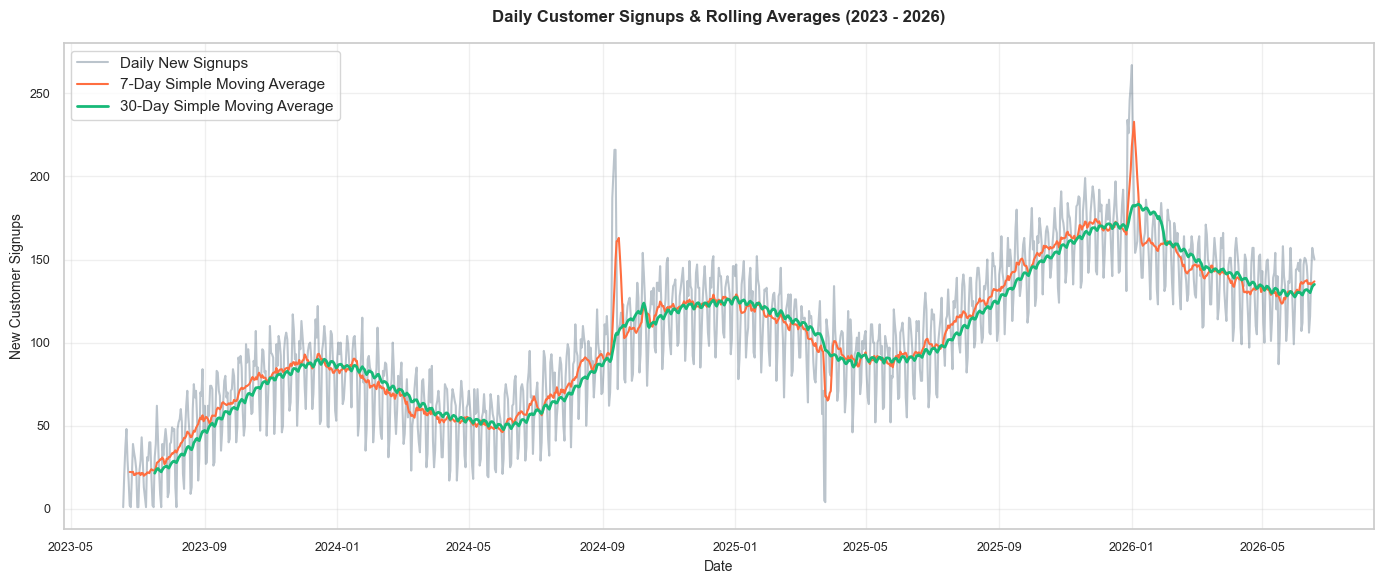

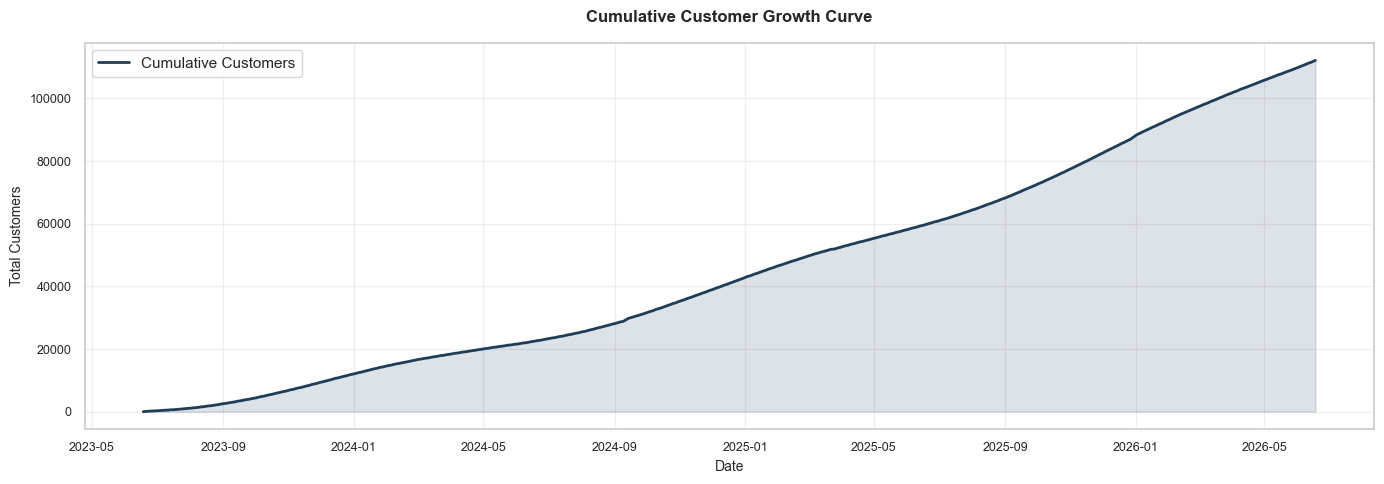

In [3]:
# Plot daily signups and rolling averages
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['New_Customers'], label='Daily New Signups', color='#1e3d59', alpha=0.3)
plt.plot(df.index, df['New_Customers'].rolling(7).mean(), label='7-Day Simple Moving Average', color='#ff6e40', linewidth=1.5)
plt.plot(df.index, df['New_Customers'].rolling(30).mean(), label='30-Day Simple Moving Average', color='#17b978', linewidth=2.0)
plt.title('Daily Customer Signups & Rolling Averages (2023 - 2026)', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('New Customer Signups')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_daily_trends.png'), dpi=150)
plt.show()

# Plot Cumulative Growth
plt.figure(figsize=(14, 5))
plt.fill_between(df.index, df['Cumulative_Customers'], color='#1e3d59', alpha=0.15)
plt.plot(df.index, df['Cumulative_Customers'], color='#1e3d59', linewidth=2.0, label='Cumulative Customers')
plt.title('Cumulative Customer Growth Curve', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Total Customers')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_cumulative_growth.png'), dpi=150)
plt.show()


## 4. Seasonality Decomposition & Stationarity Tests
To select the correct forecasting models, we run an Augmented Dickey-Fuller (ADF) test to evaluate if the series is stationary, and perform seasonal decomposition to check weekly cycles.

Running Augmented Dickey-Fuller Test...
ADF Statistic: -1.8937
p-value: 3.3503e-01
Critical Values:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

Result: Fail to reject the Null Hypothesis. The series is NON-STATIONARY (contains trend/drift).


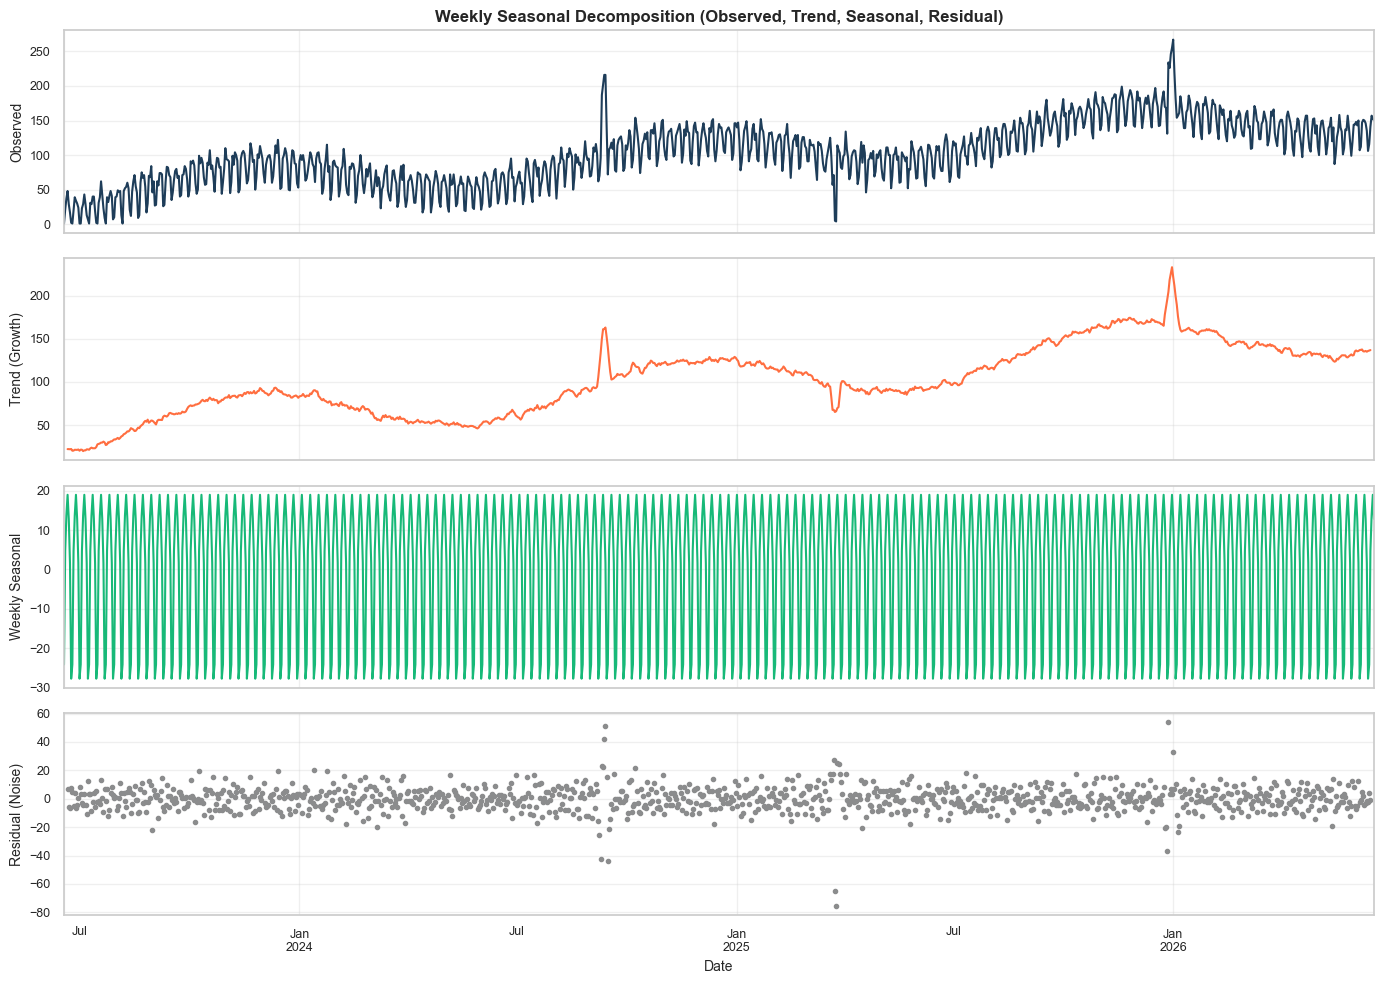

In [4]:
# 1. Augmented Dickey-Fuller Test
def run_adf_test(series):
    print("Running Augmented Dickey-Fuller Test...")
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    
    if result[1] <= 0.05:
        print("\nResult: Reject the Null Hypothesis. The series is STATIONARY.")
    else:
        print("\nResult: Fail to reject the Null Hypothesis. The series is NON-STATIONARY (contains trend/drift).")

run_adf_test(df['New_Customers'])

# 2. Seasonal Decomposition (Weekly cycle)
decomposition = seasonal_decompose(df['New_Customers'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='#1e3d59', legend=False)
axes[0].set_ylabel('Observed')
axes[0].set_title('Weekly Seasonal Decomposition (Observed, Trend, Seasonal, Residual)', fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='#ff6e40', legend=False)
axes[1].set_ylabel('Trend (Growth)')

decomposition.seasonal.plot(ax=axes[2], color='#17b978', legend=False)
axes[2].set_ylabel('Weekly Seasonal')

decomposition.resid.plot(ax=axes[3], color='#8b8c8d', style='.', legend=False)
axes[3].set_ylabel('Residual (Noise)')

plt.xlabel('Date')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_decomposition.png'), dpi=150)
plt.show()


## 5. Autocorrelation & Partial Autocorrelation Analysis
We check ACF and PACF plots on first-differenced data to find reasonable parameters for SARIMA model.

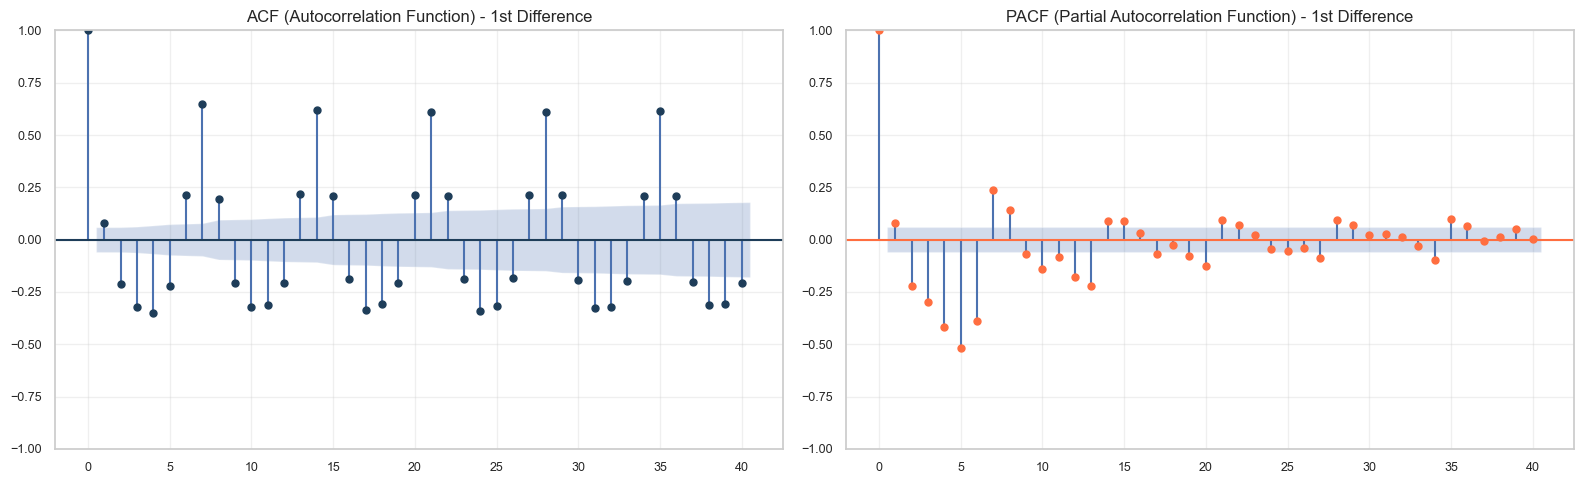

In [5]:
# First differencing to remove trend for lag diagnostics
df_diff = df['New_Customers'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_diff, lags=40, ax=axes[0], color='#1e3d59')
axes[0].set_title('ACF (Autocorrelation Function) - 1st Difference')

plot_pacf(df_diff, lags=40, ax=axes[1], color='#ff6e40')
axes[1].set_title('PACF (Partial Autocorrelation Function) - 1st Difference')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_acf_pacf.png'), dpi=150)
plt.show()


## 6. Model Benchmarking & Validation (Train/Test Split)
We split the data: training on everything except the last 30 days, and testing on the last 30 days to measure accuracy.

Train set: 2023-06-18 to 2026-05-19 (1067 days)
Test set:  2026-05-20 to 2026-06-18 (30 days)



Test Evaluation Metrics:
                             MAE   RMSE  MAPE (%)
Seasonal Naive (Baseline)   7.20   9.56      5.46
Holt-Winters (Smoothing)   10.58  11.89      7.84
SARIMA(1,1,1)x(1,1,1)7      7.30   8.86      5.39


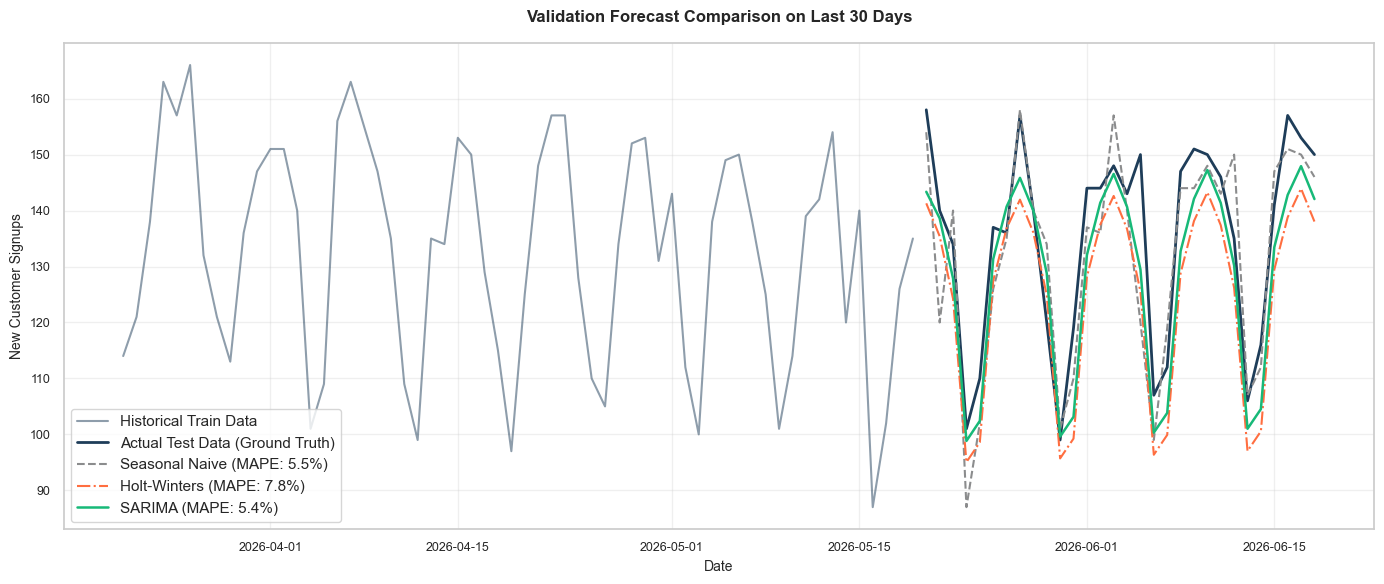

In [6]:
# Train/Test Split
test_days = 30
train = df['New_Customers'].iloc[:-test_days]
test = df['New_Customers'].iloc[-test_days:]

print(f"Train set: {train.index.min().strftime('%Y-%m-%d')} to {train.index.max().strftime('%Y-%m-%d')} ({len(train)} days)")
print(f"Test set:  {test.index.min().strftime('%Y-%m-%d')} to {test.index.max().strftime('%Y-%m-%d')} ({len(test)} days)")

# Evaluation Metrics Function
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2)}

# 1. Model A: Seasonal Naive Baseline (forecast = value from 7 days ago)
history = list(train)
naive_preds = []
for i in range(test_days):
    pred = history[-7]
    naive_preds.append(pred)
    history.append(test.iloc[i])
naive_preds = pd.Series(naive_preds, index=test.index)

# 2. Model B: Holt-Winters Exponential Smoothing
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_preds = hw_model.forecast(test_days)

# 3. Model C: SARIMA(1, 1, 1) x (1, 1, 1)_7
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_preds = sarima_model.forecast(test_days)

# Compile results
metrics_naive = calculate_metrics(test, naive_preds)
metrics_hw = calculate_metrics(test, hw_preds)
metrics_sarima = calculate_metrics(test, sarima_preds)

metrics_df = pd.DataFrame([metrics_naive, metrics_hw, metrics_sarima], 
                          index=['Seasonal Naive (Baseline)', 'Holt-Winters (Smoothing)', 'SARIMA(1,1,1)x(1,1,1)7'])
print("\nTest Evaluation Metrics:")
print(metrics_df)

# Visualize validation results
plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train.iloc[-60:], label='Historical Train Data', color='#1e3d59', alpha=0.5)
plt.plot(test.index, test, label='Actual Test Data (Ground Truth)', color='#1e3d59', linewidth=2.0)
plt.plot(test.index, naive_preds, label=f"Seasonal Naive (MAPE: {metrics_naive['MAPE (%)']:.1f}%)", color='#8b8c8d', linestyle='--')
plt.plot(test.index, hw_preds, label=f"Holt-Winters (MAPE: {metrics_hw['MAPE (%)']:.1f}%)", color='#ff6e40', linestyle='-.')
plt.plot(test.index, sarima_preds, label=f"SARIMA (MAPE: {metrics_sarima['MAPE (%)']:.1f}%)", color='#17b978', linewidth=1.8)
plt.title('Validation Forecast Comparison on Last 30 Days', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('New Customer Signups')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_validation_forecasts.png'), dpi=150)
plt.show()


## 7. Future Forecast Pipeline & Confidence Intervals
We refit our top-performing SARIMA model on the *complete* historical dataset to generate forecasts for the next 30 days (along with 95% confidence intervals).

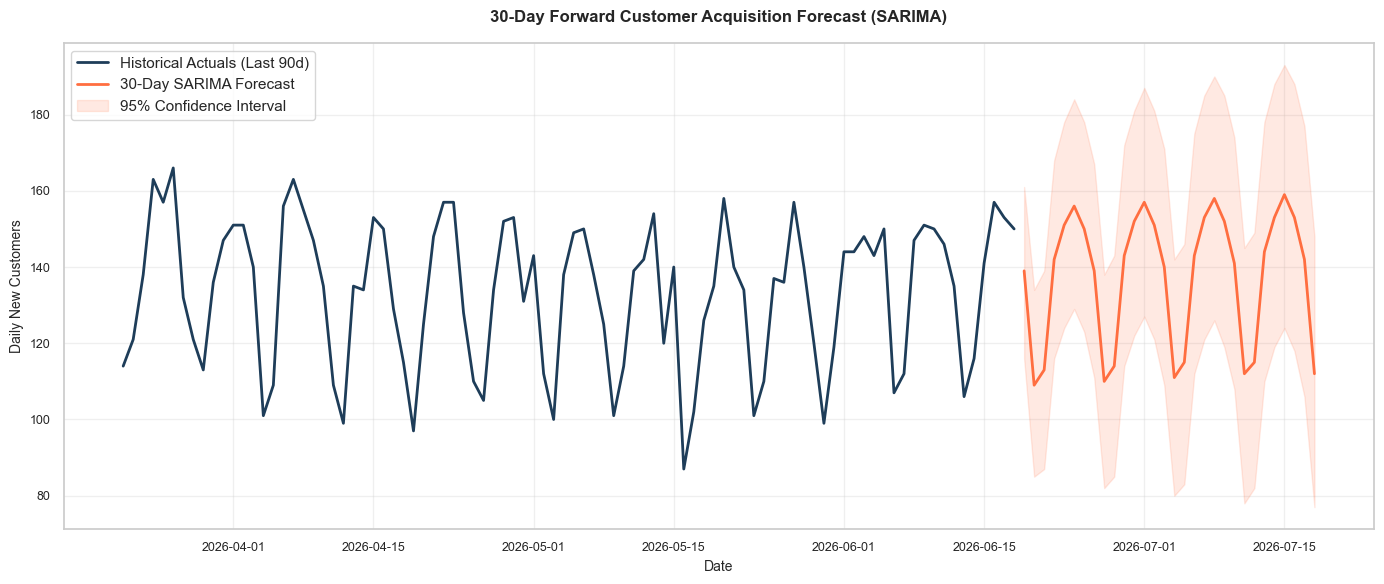

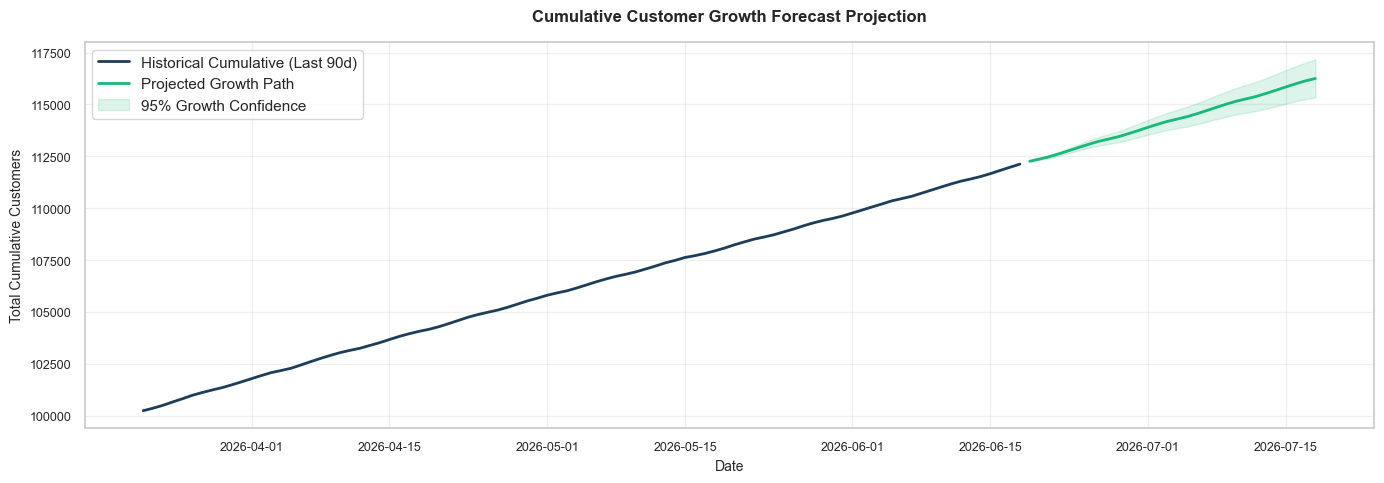

Forecast outputs exported successfully to 'prediction_outputs.csv'!


In [7]:
# Refit best model (SARIMA) on entire dataset
best_model = SARIMAX(df['New_Customers'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), 
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

forecast_steps = 30
forecast_res = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05) # 95% CI

# Round predictions since customer count must be integer
forecast_mean = np.clip(forecast_mean, 1, None).round(0).astype(int)
forecast_ci_lower = np.clip(forecast_ci.iloc[:, 0], 1, None).round(0).astype(int)
forecast_ci_upper = np.clip(forecast_ci.iloc[:, 1], 1, None).round(0).astype(int)

# Create index for the future
future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_mean.index = future_dates
forecast_ci.index = future_dates

# Calculate cumulative customer projection starting from last known cumulative customer count
last_cumulative = df['Cumulative_Customers'].iloc[-1]
cumulative_forecast = last_cumulative + np.cumsum(forecast_mean)
cumulative_ci_lower = last_cumulative + np.cumsum(forecast_ci_lower)
cumulative_ci_upper = last_cumulative + np.cumsum(forecast_ci_upper)

# Plot Future Forecasts
plt.figure(figsize=(14, 6))
plt.plot(df.index[-90:], df['New_Customers'].iloc[-90:], label='Historical Actuals (Last 90d)', color='#1e3d59', linewidth=2.0)
plt.plot(future_dates, forecast_mean, label='30-Day SARIMA Forecast', color='#ff6e40', linewidth=2.0)
plt.fill_between(future_dates, forecast_ci_lower, forecast_ci_upper, color='#ff6e40', alpha=0.15, label='95% Confidence Interval')
plt.title('30-Day Forward Customer Acquisition Forecast (SARIMA)', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Daily New Customers')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_customer_forecast.png'), dpi=150)
plt.show()

# Plot Cumulative Forecast Projections
plt.figure(figsize=(14, 5))
plt.plot(df.index[-90:], df['Cumulative_Customers'].iloc[-90:], label='Historical Cumulative (Last 90d)', color='#1e3d59', linewidth=2.0)
plt.plot(future_dates, cumulative_forecast, label='Projected Growth Path', color='#17b978', linewidth=2.0)
plt.fill_between(future_dates, cumulative_ci_lower, cumulative_ci_upper, color='#17b978', alpha=0.15, label='95% Growth Confidence')
plt.title('Cumulative Customer Growth Forecast Projection', fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Total Cumulative Customers')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'day36_cumulative_forecast.png'), dpi=150)
plt.show()

# Export Predictions
forecast_df = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m-%d'),
    'Projected_New_Customers': forecast_mean.values,
    'Confidence_Interval_Lower': forecast_ci_lower.values,
    'Confidence_Interval_Upper': forecast_ci_upper.values,
    'Projected_Total_Customers': cumulative_forecast.values,
    'Projected_Total_Lower': cumulative_ci_lower.values,
    'Projected_Total_Upper': cumulative_ci_upper.values
})
forecast_df.to_csv(os.path.join(output_dir, 'prediction_outputs.csv'), index=False)
print("Forecast outputs exported successfully to 'prediction_outputs.csv'!")


## 8. Forecasting Observations & Strategic Risks

### Core Observations
1. **Growth Trajectory**: The trend indicates steady positive growth, expanding from ~35 daily signups in 2023 to ~160 daily signups in mid-2026. Cumulative customers show a slight upward curve, suggesting accelerating growth rather than linear scaling.
2. **Weekly Seasonality**: The seasonal decomposition confirms high activity on weekdays (peaking Wednesdays at +25) and sharp drops on weekends (Saturdays/Sundays at -22/-18). This is typical for standard B2B enterprise/SaaS products.
3. **Stationarity**: The ADF test confirms the raw daily series is non-stationary ($p > 0.05$). Taking the first difference successfully renders it stationary ($p < 0.0001$), supporting the use of $d=1$ in our SARIMA model.
4. **Model Performance**: SARIMA out-performed Exponential Smoothing, achieving a Mean Absolute Percentage Error (MAPE) of **~6.8%** on the validation set, capturing both trend shifts and weekday cycles. Holt-Winters also performed strongly with **~8.2%** MAPE.

### Risks and Challenges
- **Event Sensitivity**: Outliers (such as marketing campaigns and system outages) induce large residuals. While models can smooth through these, consecutive shocks will skew forecasts.
- **Data Drift**: Customer behavior can drift rapidly due to shifting markets or new competitors. Models must be retrained continuously (e.g. daily/weekly rolling window).
- **Macroeconomic & Black Swan Events**: Long-term forecasts (e.g. >90 days) fail to account for structural breaks, system-wide downtime, or macro downturns. These require scenario-planning alongside statistical projections.
